# 📉 Customer Churn Prediction & Retention Analysis


**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

**Machine Learning Algorithms:**
- Logistic Regression
- Decision Tree
- Random Forest

**Objective:**
Develop a machine learning model to predict customer churn and identify the key factors influencing customer retention.

# 📌 Business Problem

Customer churn is a major challenge for subscription-based businesses because acquiring a new customer is significantly more expensive than retaining an existing one.

The objective of this project is to predict whether a customer is likely to churn using demographic information, service usage, contract details, and billing information.

Accurate churn prediction enables businesses to identify at-risk customers early and implement targeted retention strategies.

# 🎯 Project Objectives

This project aims to:

- Understand customer characteristics
- Explore factors influencing churn
- Build predictive machine learning models
- Compare multiple classification algorithms
- Identify the most important churn drivers
- Recommend business strategies for improving customer retention

# 📂 Dataset Description

The dataset contains customer information collected from a telecom company.

Features include:

- Customer demographics
- Partner & Dependents
- Phone and Internet services
- Contract type
- Payment method
- Monthly charges
- Total charges
- Customer tenure

Target Variable:

**Churn**

- Yes
- No

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 📊 Load Dataset

The dataset is loaded into a Pandas DataFrame for inspection, cleaning, visualization, and machine learning.

# 🔍 Initial Data Exploration

Before preprocessing, we examine the dataset to understand:

- Number of observations
- Number of features
- Data types
- Missing values
- Duplicate records

# 🧹 Data Cleaning & Preprocessing

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum().sum()

np.int64(0)

In [ ]:
(df["TotalCharges"]==" ").sum()

np.int64(11)

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipykernel_1594/1479199042.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning Summary

The following preprocessing steps were completed:

- Converted TotalCharges to numeric format
- Replaced missing values using the median
- Removed CustomerID since it is not predictive
- Verified that no missing values remain
- Prepared the dataset for exploratory analysis and model development

In [ ]:
df.drop("customerID", axis=1, inplace=True)

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


# 📊 Exploratory Data Analysis

The purpose of Exploratory Data Analysis (EDA) is to understand the underlying patterns in customer behavior, identify factors associated with churn, and generate insights that guide feature engineering and model development.

## Churn Distribution

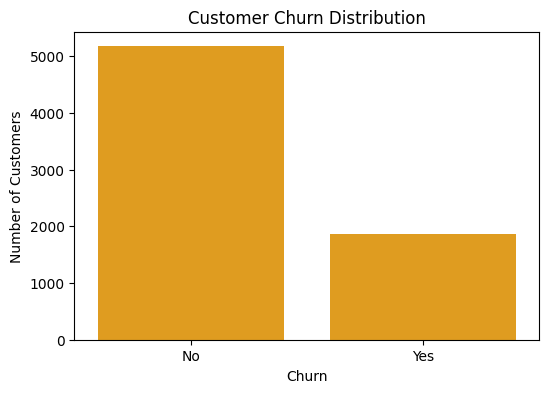

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df, color = 'orange')

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

Most customers did not churn, while a smaller proportion discontinued the service. This indicates that the dataset is moderately imbalanced.

##Distribution of Tenure

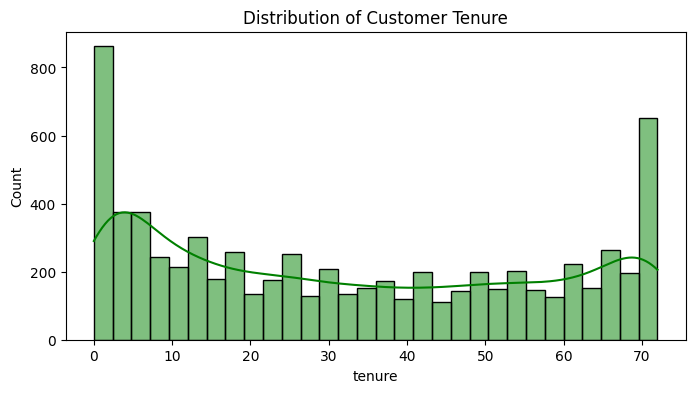

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(df['tenure'], bins=30, kde=True, color = 'green')

plt.title("Distribution of Customer Tenure")

plt.show()

This chart shows how long customers have stayed with the company. It helps identify whether most customers are new or long-term subscribers.

##Distribution of Monthly Charges

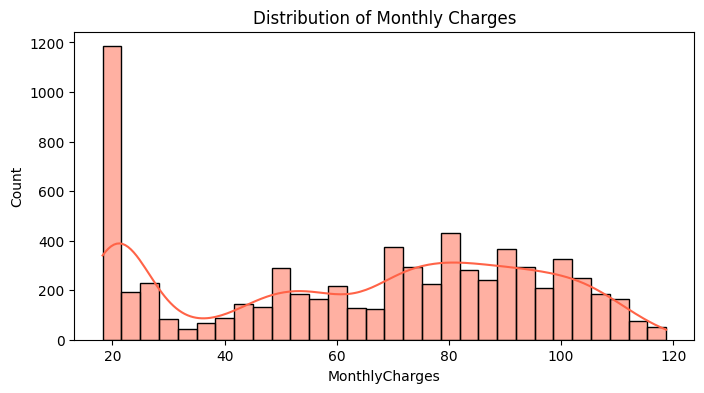

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(df['MonthlyCharges'], bins=30, kde=True, color = 'tomato')

plt.title("Distribution of Monthly Charges")

plt.show()

This visualization shows the distribution of monthly charges paid by customers and highlights the pricing patterns across the customer base.

##Tenure vs Monthly Charges

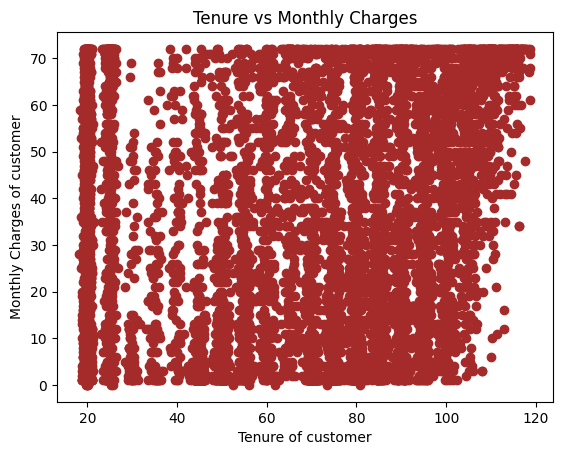

In [ ]:
plt.scatter(df['MonthlyCharges'] , df['tenure'] , color = 'brown')
plt.xlabel("Tenure of customer")
plt.ylabel("Monthly Charges of customer")
plt.title("Tenure vs Monthly Charges")
plt.show()

##Churn vs Contract

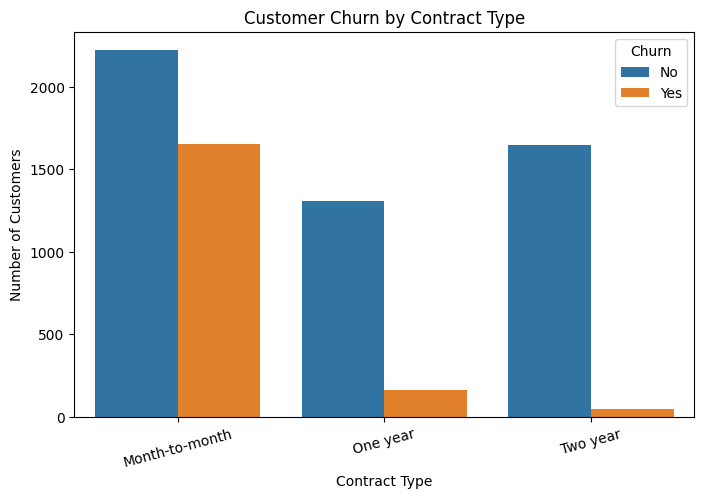

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Contract', hue='Churn')

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)

plt.show()

### Key Findings

Customers with Month-to-month contracts have the highest number of churn cases. In contrast, customers with One-year and especially Two-year contracts show significantly lower churn rates. This suggests that customers on long-term contracts are more likely to remain with the company.

Business Insight

Offering incentives for customers to switch from month-to-month plans to long-term contracts could help reduce customer churn and improve customer retention.

##Churn vs Internet Service

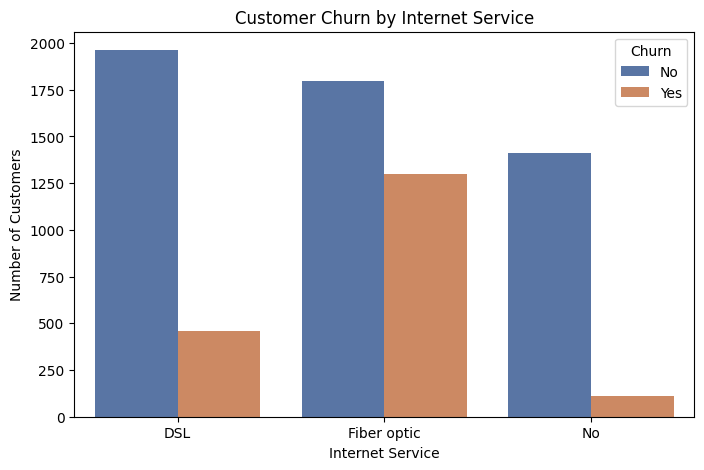

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='InternetService',
    hue='Churn',
    palette=['#4C72B0', '#DD8452']
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### Key Findings

Customers using Fiber optic internet service have the highest churn compared to DSL and customers without internet service. Customers with no internet service have the lowest churn.

Business Insight

The higher churn among Fiber optic customers may indicate issues related to pricing, service quality, or customer expectations. Improving service quality or offering loyalty benefits to Fiber optic customers could help reduce churn.

##Churn vs Payment Method

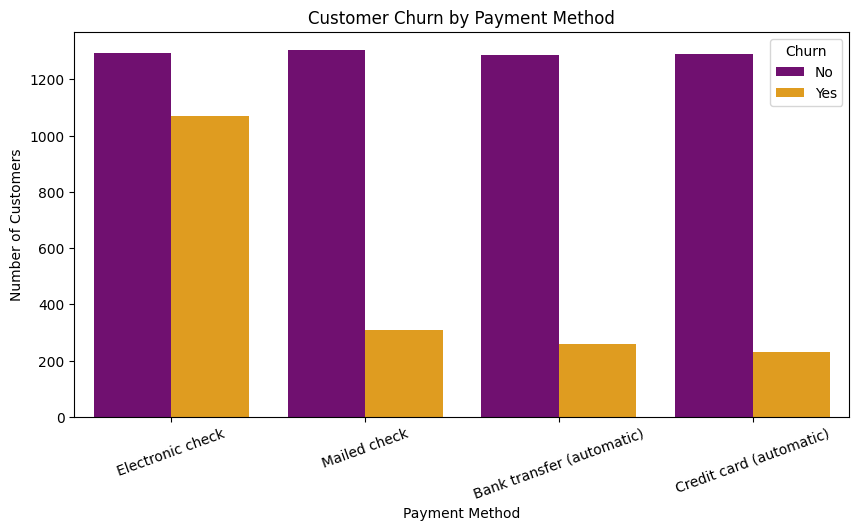

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='PaymentMethod',
    hue='Churn',
     palette=['purple', 'orange']
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

### Key Findings

Customers using Electronic Check have the highest number of churn cases compared to other payment methods. Customers using Bank Transfer (Automatic) and Credit Card (Automatic) show considerably lower churn rates.

Business Insight

Encouraging customers to switch from Electronic Check to automatic payment methods may improve customer retention and reduce churn.

##Correlation Heatmap

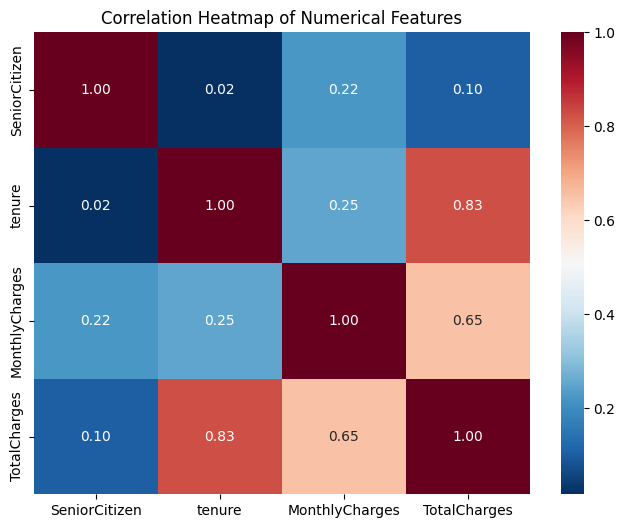

In [ ]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu_r',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

### Key Findings
The strongest positive correlation (0.83) exists between Tenure and TotalCharges, indicating that customers who stay with the company longer accumulate higher total charges. MonthlyCharges also has a moderate positive relationship (0.65) with TotalCharges, while SeniorCitizen has only weak correlations with the remaining numerical variables.

Business Insight

Customer tenure is strongly associated with total revenue generated. Improving customer retention can increase customer lifetime value and overall business revenue.

# ⚙️ Feature Engineering

Machine learning algorithms require numerical input.

Categorical variables are encoded using one-hot encoding to transform them into a format suitable for model training.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Churn"] = le.fit_transform(df["Churn"])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False



# 🤖 Machine Learning Models

Three classification algorithms are developed and compared:

- Logistic Regression
- Decision Tree
- Random Forest

The objective is to identify the model that provides the best balance between predictive performance and interpretability.

In [ ]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [ ]:
from sklearn.model_selection import train_test_split

## Train-Test Split

The dataset is divided into training and testing subsets.

- Training Set: 80%
- Testing Set: 20%

Stratified sampling is used to preserve the original churn distribution.

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X, y, test_size = 0.20, random_state= 76, stratify = y)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(x_train)

In [ ]:
X_test_scaled = scaler.transform(x_test)

## Feature Scaling
Feature scaling standardizes numerical variables so that each feature contributes equally to Logistic Regression. The scaler is fitted only on the training data to prevent data leakage.

# 🤖 Model Development

Three supervised machine learning algorithms are developed and compared to predict customer churn. Their performance is evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC to identify the most suitable model.

## Logistic Regression

Logistic Regression serves as the baseline classification model due to its simplicity, interpretability, and effectiveness for binary classification problems.

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
LR_Model = LogisticRegression()

In [ ]:
LR_Model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred_lr= LR_Model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy :", accuracy_lr)

Accuracy : 0.8026969481902059


In [ ]:
print(confusion_matrix(y_test, y_pred_lr))

[[933 102]
 [176 198]]


In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



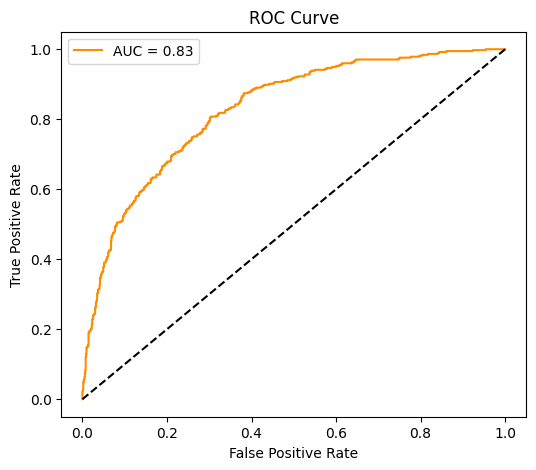

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = LR_Model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr,
         label=f"AUC = {roc_auc:.2f}",
         color="darkorange")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

Observation: The ROC curve lies well above the diagonal baseline, indicating that the Logistic Regression model effectively distinguishes between customers who churn and those who do not. The model achieved an AUC score of 0.83, which reflects strong classification performance.

## Decision Tree

Decision Trees capture non-linear relationships and provide an interpretable set of decision rules.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)

In [ ]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy :", accuracy_dt)

print(confusion_matrix(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Accuracy : 0.7068843151171044
[[821 214]
 [199 175]]
              precision    recall  f1-score   support

           0       0.80      0.79      0.80      1035
           1       0.45      0.47      0.46       374

    accuracy                           0.71      1409
   macro avg       0.63      0.63      0.63      1409
weighted avg       0.71      0.71      0.71      1409



Applying Hyper-parameter tuning to try all possible combinations of parameter to get best accuracy.

Hyperparameter tuning was performed using GridSearchCV to identify the optimal Decision Tree parameters and improve model performance.

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
new_model = DecisionTreeClassifier()

In [ ]:
grid_params ={  "criterion":["gini" , "entropy"] , 'max_depth':[1,5,8,10,12,15,20,45,56,100]  ,  'random_state' :[0,10,20,42,60,66,100,200]
              , 'min_samples_split':[2,6,3,4,5,66,7,8] , 'min_samples_leaf' :[1,4,4,5,6,88,99]}

In [ ]:
gv = GridSearchCV(estimator=new_model , param_grid = grid_params , cv= 3 )

In [ ]:
gv.fit(x_train , y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 5, 8, 10, 12, 15, 20, 45, 56, 100],
                         'min_samples_leaf': [1, 4, 4, 5, 6, 88, 99],
                         'min_samples_split': [2, 6, 3, 4, 5, 66, 7, 8],
                         'random_state': [0, 10, 20, 42, 60, 66, 100, 200]})

In [ ]:
dt_model =gv.best_estimator_

In [ ]:
y_pred_1 = dt_model.predict(x_test)

In [ ]:
Dt_accuracy = accuracy_score(y_test,y_pred_1)

In [ ]:
Dt_accuracy

0.7849538679914834

In [ ]:
print(confusion_matrix(y_test, y_pred_1))

print(classification_report(y_test, y_pred_1))

[[958  77]
 [226 148]]
              precision    recall  f1-score   support

           0       0.81      0.93      0.86      1035
           1       0.66      0.40      0.49       374

    accuracy                           0.78      1409
   macro avg       0.73      0.66      0.68      1409
weighted avg       0.77      0.78      0.77      1409



## Random Forest

Random Forest combines multiple decision trees through ensemble learning to improve predictive performance and reduce overfitting.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy :", accuracy_rf)

print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy : 0.7920511000709723
[[934 101]
 [192 182]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [ ]:
#  Use Different values of n_estimator to find which optimal no of DT is going to give us highest accuracy in Random Forest

n=[50,100,200,300,400,500,600,700,800,900,1000]

accuracy = [ ]   # In this list i am going to store all the accuracy

for i in n:
  model = RandomForestClassifier(n_estimators=i)
  model.fit(x_train , y_train)                      # Training the model
  prdcn =model.predict(x_test)                        # Testing the model
  RF_accuracy=accuracy_score(y_test,prdcn)
  accuracy.append(RF_accuracy)

In [ ]:
accuracy

[0.7814052519517388,
 0.7806955287437899,
 0.7849538679914834,
 0.7885024840312278,
 0.7863733144073811,
 0.7849538679914834,
 0.7885024840312278,
 0.7885024840312278,
 0.7885024840312278,
 0.7806955287437899,
 0.7899219304471257]

In [ ]:
d={"Number of Trees" : n , "Accuracy of them in RF":accuracy}
df=pd.DataFrame(d)
df

,Number of Trees,Accuracy of them in RF
0,50,0.781405
1,100,0.780696
2,200,0.784954
3,300,0.788502
4,400,0.786373
5,500,0.784954
6,600,0.788502
7,700,0.788502
8,800,0.788502
9,900,0.780696


# 📈 Feature Importance

The Random Forest model is used to identify the variables that contribute most to predicting customer churn.

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.190897
1,tenure,0.177484
2,MonthlyCharges,0.169740
10,InternetService_Fiber optic,0.043443
28,PaymentMethod_Electronic check,0.031232
4,gender_Male,0.028376
13,OnlineSecurity_Yes,0.028226
25,Contract_Two year,0.027259
26,PaperlessBilling_Yes,0.026208
5,Partner_Yes,0.023006


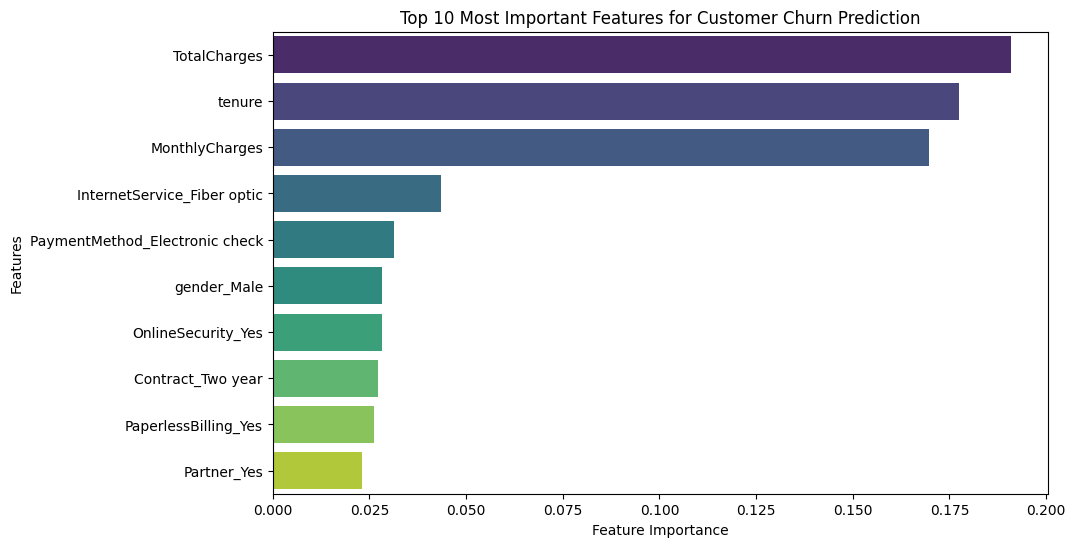

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title("Top 10 Most Important Features for Customer Churn Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.show()

The Random Forest model identified Total Charges, Tenure and Monthly Charges as the most influential predictors of customer churn. These variables play a significant role in distinguishing customers who are likely to leave the company. Businesses can use these insights to focus retention efforts on customers with short tenure, month-to-month contracts, and higher monthly charges.

# 📊 Model Comparison

The three classification models are evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The best-performing model is selected based on overall predictive performance.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        Dt_accuracy,
        accuracy_rf
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_1),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_1),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_1),
        f1_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.802697,0.660000,0.529412,0.587537
1,Decision Tree,0.784954,0.657778,0.395722,0.494157
2,Random Forest,0.792051,0.643110,0.486631,0.554033


Three machine learning algorithms—Logistic Regression, Decision Tree, and Random Forest—were trained and evaluated using Accuracy, Precision, Recall, and F1-Score. Among the three models, Logistic Regression achieved the best overall performance with an Accuracy of 80.27%, Precision of 66.00%, Recall of 52.94%, and an F1-Score of 58.75%. Random Forest produced competitive results but did not outperform Logistic Regression, while Decision Tree showed the lowest overall performance.

# 📝 Conclusion


This project successfully developed a machine learning solution to predict customer churn using customer demographic, service, and billing information. After data preprocessing, exploratory data analysis, and model development, three classification algorithms—Logistic Regression, Decision Tree, and Random Forest—were evaluated.

Among the models, **Logistic Regression** achieved the best overall performance with an **Accuracy of 80.27%** and an **ROC-AUC score of 0.83**, making it the most suitable model for this dataset. The analysis also identified **Contract Type, Tenure, Monthly Charges, Total Charges, and Internet Service** as the most influential factors affecting customer churn.

Overall, this project demonstrates how machine learning can help businesses identify customers at risk of churn and support data-driven retention strategies, ultimately improving customer satisfaction and long-term business performance.


# 💼 Business Recommendations

Based on the analysis, the following strategies can help reduce customer churn:

1. Promote long-term contracts.
2. Improve the Fiber Optic customer experience.
3. Encourage automatic payment methods.
4. Design retention campaigns for new customers.
5. Monitor customers with high monthly charges.
6. Develop loyalty programs for high-risk customer segments.